In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import sqlite3
import json

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_movies.csv
/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata/tmdb_5000_credits.csv


# Asignación 3: Diseño, Normalización e Implementación de Base de Datos Relacional

**Dataset:** TMDB 5000 Movie Dataset  
**Herramientas:** Kaggle Notebook, Python, Pandas, SQLite, draw.io  
**Base de datos generada:** `tmdb_normalized.db`

## Objetivo
Transformar datos semi-estructurados en formato CSV/JSON del dataset TMDB en un modelo relacional normalizado, implementar la base de datos en SQLite y ejecutar consultas analíticas.

In [2]:
import pandas as pd
import sqlite3
import ast
from pathlib import Path

input_dir = Path("/kaggle/input/datasets/organizations/tmdb/tmdb-movie-metadata")

movies_path = input_dir / "tmdb_5000_movies.csv"
credits_path = input_dir / "tmdb_5000_credits.csv"

movies = pd.read_csv(movies_path)
credits = pd.read_csv(credits_path)

print("Movies shape:", movies.shape)
print("Credits shape:", credits.shape)

display(movies.head(3))
display(credits.head(3))

Movies shape: (4803, 20)
Credits shape: (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


,movie_id,title,cast,crew
0,19995,Avatar,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de..."
1,285,Pirates of the Caribbean: At World's End,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de..."
2,206647,Spectre,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de..."


## Análisis inicial de columnas JSON

Al revisar los archivos se observa que algunas columnas contienen listas en formato JSON. Estas columnas no son atómicas porque guardan múltiples valores dentro de una sola celda.

En `movies`, las columnas con valores múltiples son:

- `genres`
- `keywords`
- `production_companies`
- `production_countries`
- `spoken_languages`

En `credits`, las columnas con valores múltiples son:

- `cast`
- `crew`

Estas columnas deben separarse en tablas independientes para cumplir con la Primera Forma Normal.

In [3]:
# Las columnas disponibles en cada archivo

print("Columnas de movies:")
print(movies.columns.tolist())

print("\nColumnas de credits:")
print(credits.columns.tolist())

Columnas de movies:
['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']

Columnas de credits:
['movie_id', 'title', 'cast', 'crew']


In [4]:
# Ejemplos de columnas JSON / multivaluadas

json_columns_movies = [
    "genres",
    "keywords",
    "production_companies",
    "production_countries",
    "spoken_languages"
]

json_columns_credits = ["cast", "crew"]

for col in json_columns_movies:
    print(f"\nEjemplo de movies['{col}']:")
    print(movies[col].iloc[0])

for col in json_columns_credits:
    print(f"\nEjemplo de credits['{col}']:")
    print(credits[col].iloc[0][:500], "...")


Ejemplo de movies['genres']:
[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]

Ejemplo de movies['keywords']:
[{"id": 1463, "name": "culture clash"}, {"id": 2964, "name": "future"}, {"id": 3386, "name": "space war"}, {"id": 3388, "name": "space colony"}, {"id": 3679, "name": "society"}, {"id": 3801, "name": "space travel"}, {"id": 9685, "name": "futuristic"}, {"id": 9840, "name": "romance"}, {"id": 9882, "name": "space"}, {"id": 9951, "name": "alien"}, {"id": 10148, "name": "tribe"}, {"id": 10158, "name": "alien planet"}, {"id": 10987, "name": "cgi"}, {"id": 11399, "name": "marine"}, {"id": 13065, "name": "soldier"}, {"id": 14643, "name": "battle"}, {"id": 14720, "name": "love affair"}, {"id": 165431, "name": "anti war"}, {"id": 193554, "name": "power relations"}, {"id": 206690, "name": "mind and soul"}, {"id": 209714, "name": "3d"}]

Ejemplo de movies['production_companies']:
[{"name": "Ingenious Fi

## Diagrama Entidad-Relación (E/R)

El diagrama E/R representa el modelo conceptual del dataset TMDB 5000. La entidad principal es `Movie`, ya que toda la información gira alrededor de las películas.

El análisis inicial muestra que una película puede tener múltiples géneros, palabras clave, compañías productoras, países de producción, lenguajes, actores y miembros del equipo técnico. Por esta razón, varias relaciones son de muchos a muchos (M:N).

Estas relaciones luego serán convertidas en tablas puente durante el modelo relacional.

## Imagen del Diagrama Entidad-Relación

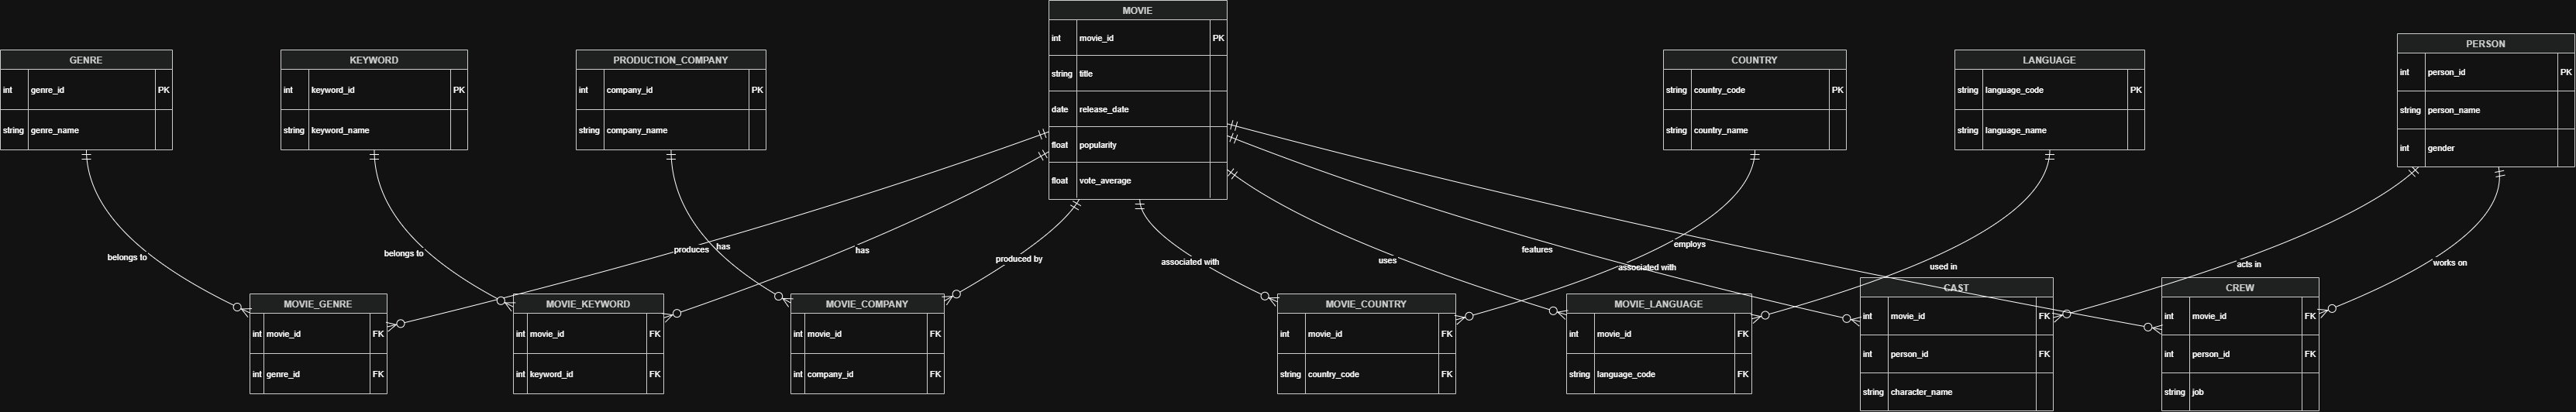

## Traducción del E/R al esquema lógico y normalización

### Primera Forma Normal (1NF)

La Primera Forma Normal establece que cada atributo debe contener valores atómicos, esto queiere decir, solo se encuntra un solo valor por celda. En el dataset original de TMDB, algunas columnas no cumplen con esta regla porque contienen listas en formato JSON dentro de una misma celda.

Las columnas que violan 1NF son:

**En `tmdb_5000_movies.csv`:**
- `genres`
- `keywords`
- `production_companies`
- `production_countries`
- `spoken_languages`

**En `tmdb_5000_credits.csv`:**
- `cast`
- `crew`

Estas columnas contienen grupos repetitivos. Por ejemplo, una misma película puede tener varios géneros, varios idiomas, varios actores y varios miembros del equipo técnico. Si estos valores se dejan dentro de una sola celda, la tabla no está normalizada.

Para cumplir con 1NF, las listas JSON se separan en tablas independientes. Además, se crean tablas puente para mantener la relación entre cada película y sus valores múltiples.

Ejemplo de transformación:

- `genres` se separa en una tabla `genres` y una tabla puente `movie_genres`.
- `spoken_languages` se separa en una tabla `languages` y una tabla puente `movie_spoken_languages`.
- `cast` se separa en una tabla `people` y una tabla puente `movie_cast`.

De esta forma, cada fila contiene un solo valor por atributo y se eliminan los grupos repetitivos del dataset original.

In [5]:
# Columnas que violan 1NF porque contienen listas JSON

print("Ejemplo de genres:")
print(movies["genres"].iloc[0])

print("\nEjemplo de spoken_languages:")
print(movies["spoken_languages"].iloc[0])

print("\nEjemplo de cast:")
print(credits["cast"].iloc[0][:500], "...")

Ejemplo de genres:
[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id": 878, "name": "Science Fiction"}]

Ejemplo de spoken_languages:
[{"iso_639_1": "en", "name": "English"}, {"iso_639_1": "es", "name": "Espa\u00f1ol"}]

Ejemplo de cast:
[{"cast_id": 242, "character": "Jake Sully", "credit_id": "5602a8a7c3a3685532001c9a", "gender": 2, "id": 65731, "name": "Sam Worthington", "order": 0}, {"cast_id": 3, "character": "Neytiri", "credit_id": "52fe48009251416c750ac9cb", "gender": 1, "id": 8691, "name": "Zoe Saldana", "order": 1}, {"cast_id": 25, "character": "Dr. Grace Augustine", "credit_id": "52fe48009251416c750aca39", "gender": 1, "id": 10205, "name": "Sigourney Weaver", "order": 2}, {"cast_id": 4, "character": "Col. Quaritch", "c ...


In [6]:
def parse_json_list(value):
    """
    Este bloque convierte una columna tipo JSON/string a una lista de diccionarios.
    Si el valor está vacío o tiene error, devuelve una lista vacía.
    """
    if pd.isna(value):
        return []
    
    try:
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return parsed
        return []
    except Exception:
        return []

In [7]:
# Aplicación de 1NF a la columna genres

genres_rows = []
movie_genres_rows = []

for _, row in movies.iterrows():
    movie_id = row["id"]
    genres_list = parse_json_list(row["genres"])
    
    for genre in genres_list:
        genres_rows.append({
            "genre_id": genre["id"],
            "genre_name": genre["name"]
        })
        
        movie_genres_rows.append({
            "movie_id": movie_id,
            "genre_id": genre["id"]
        })

genres = pd.DataFrame(genres_rows).drop_duplicates()
movie_genres = pd.DataFrame(movie_genres_rows).drop_duplicates()

print("Tabla genres:")
display(genres.head())

print("Tabla puente movie_genres:")
display(movie_genres.head())

Tabla genres:


,genre_id,genre_name
0,28,Action
1,12,Adventure
2,14,Fantasy
3,878,Science Fiction
9,80,Crime


Tabla puente movie_genres:


,movie_id,genre_id
0,19995,28
1,19995,12
2,19995,14
3,19995,878
4,285,12


### Resultado de 1NF

La columna `genres` originalmente contenía una lista JSON dentro de una sola celda. Para poder cumplir con 1NF, esa lista fue separada en dos tablas:

- `genres`: contiene el catálogo de géneros.
- `movie_genres`: conecta cada película con sus géneros.

Esto elimina los valores multivaluados y permite que cada celda contenga un solo dato. La misma lógica se aplicará a las demás columnas JSON del dataset, como `keywords`, `spoken_languages`, `production_companies`, `production_countries`, `cast` y `crew`.

### Segunda Forma Normal (2NF)

La Segunda Forma Normal establece que la tabla debe estar en 1NF y que todos los atributos no clave deben depender completamente de la llave primaria.

En este diseño, varias relaciones usan tablas puente con llaves compuestas. Un ejemplo de este es la tabla `movie_genres` ya que tiene una llave compuesta formada por:

- `movie_id`
- `genre_id`

Si se guardara `genre_name` directamente en `movie_genres`, habría una dependencia parcial, porque `genre_name` depende únicamente de `genre_id`, no de la combinación completa `movie_id + genre_id`.

Para evitar esta dependencia parcial, se separan los datos descriptivos en tablas maestras o catálogos.

Ejemplo:

- `genres` guarda los datos propios del género.
- `movie_genres` solo guarda la relación entre películas y géneros.

Esta misma lógica se aplica a keywords, compañías productoras, países, lenguajes y personas.

In [8]:
# Ejemplo de problema que 2NF evita:
# En esta tabla mezcla la relación movie_id + genre_id con el dato descriptivo genre_name.

movie_genres_incorrecta = movie_genres.merge(genres, on="genre_id", how="left")

print("Ejemplo de tabla que NO sería ideal en 2NF:")
display(movie_genres_incorrecta.head(10))

print("Tabla catálogo genres:")
display(genres.head())

print("Tabla puente movie_genres:")
display(movie_genres.head())

Ejemplo de tabla que NO sería ideal en 2NF:


,movie_id,genre_id,genre_name
0,19995,28,Action
1,19995,12,Adventure
2,19995,14,Fantasy
3,19995,878,Science Fiction
4,285,12,Adventure
5,285,14,Fantasy
6,285,28,Action
7,206647,28,Action
8,206647,12,Adventure
9,206647,80,Crime


Tabla catálogo genres:


,genre_id,genre_name
0,28,Action
1,12,Adventure
2,14,Fantasy
3,878,Science Fiction
9,80,Crime


Tabla puente movie_genres:


,movie_id,genre_id
0,19995,28
1,19995,12
2,19995,14
3,19995,878
4,285,12


### Resultado de 2NF

La tabla `movie_genres_incorrecta` muestra el problema que se evita con 2NF: repetir `genre_name` en cada relación entre película y género.

La manera correcta para separa la información es de la manera siguiente:

- `genres(genre_id, genre_name)`
- `movie_genres(movie_id, genre_id)`

Así, `genre_name` depende completamente de la llave primaria de `genres`, y `movie_genres` solo representa la relación entre películas y géneros.

Este principio tambien se puede aplicar a:

- `keywords` y `movie_keywords`
- `production_companies` y `movie_production_companies`
- `etc`